In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# some constants
omegb = 0.02226 # omega_b * h**2

######################3
#
# Lambda CDM

# E(z) squared
def Esq(z, Om):
    return Om*(1+z)**3 + 1 - Om

# inverse E(z)
def Einv(z, Efunc, param):
    return 1/np.sqrt(Efunc(z, param))

# integral of 1/E(z) with solve_ivp
def intdif(z, Efunc, param):
    Ei = lambda x, y: Einv(x, Efunc, param)
    sol = solve_ivp(Ei, [0, z[-1]],[0], t_eval=z)
    return sol.y.flatten()

Text(0, 0.5, 'magnitudes aparentes')

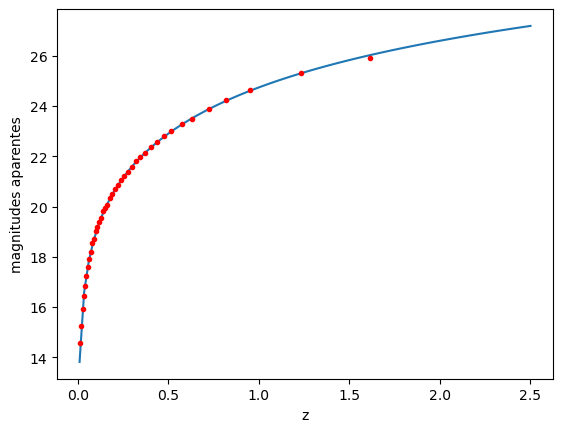

In [22]:
# read supernovae data
z, mb, dmb = np.loadtxt('../data/binned.txt', usecols=(2,4,5), unpack=True, skiprows=1)
z, idsort = np.unique(z, return_index=True) 
mb = mb[idsort]
dmb = dmb[idsort]

#M = -19.36; h = 0.7; Om = 0.3
M = -19.36; h = 0.7; Om = 0.3
#c/H0 = 3000/0.7
M_curl = M + 25  + 5 *np.log10 (3000/h)    # M_curl = 23.80  

zv = np.linspace(0.01,2.5,100)
d_sn = (1+zv)*intdif(zv, Esq, Om)
m_th = M_curl + 5*np.log10(d_sn)


plt.plot(zv,m_th)
plt.errorbar(z, mb, fmt='.', yerr=dmb, color='r')
plt.xlabel('z')
plt.ylabel('magnitudes aparentes')

In [24]:
# ler dados de pantheon+
data = np.genfromtxt('../data/Pantheon+SH0ES.dat',names=True, dtype=None, encoding=None)
# Hubble flow only: drop calibrators and very low-z
mask = (data['IS_CALIBRATOR'] == 0) & (data['zHD'] > 0.01)
z   = data['zHD'][mask]
mb  = data['m_b_corr'][mask]
dmb = data['m_b_corr_err_DIAG'][mask]

Text(0, 0.5, 'magnitudes aparentes')

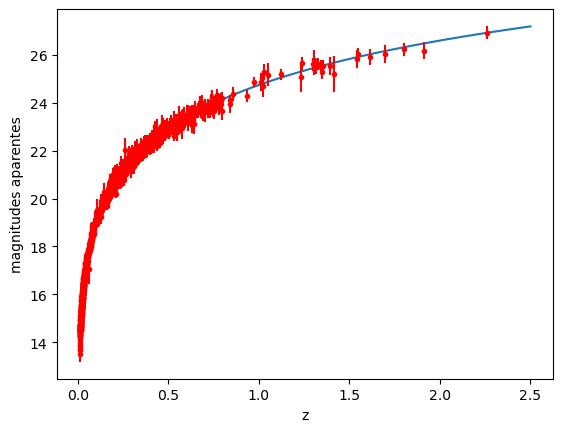

In [25]:
plt.plot(zv,m_th)
plt.errorbar(z, mb, fmt='.', yerr=dmb, color='r')
plt.xlabel('z')
plt.ylabel('magnitudes aparentes')